In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB,BernoulliNB
from sklearn.metrics import(
accuracy_score,
precision_score,
recall_score,
f1_score,confusion_matrix,
roc_curve,
auc
)

In [40]:
train_data = fetch_20newsgroups(subset="train",remove=("headers","footers","quotes"))

In [41]:
test_data = fetch_20newsgroups(subset="test",remove=("headers","footers","quotes"))

In [42]:
X_train_text =train_data.data
y_train = train_data.target

X_test_text =test_data.data
y_test = test_data.target

class_names =train_data.target_names

In [43]:
print("Training documents :",len(X_train_text))
print("Testing documents :",len(X_test_text))
print("Number of classes :",len(class_names))

Training documents : 11314
Testing documents : 7532
Number of classes : 20


In [44]:
vectorizer=CountVectorizer(
    stop_words="english",min_df=2)
X_train=vectorizer.fit_transform(X_train_text)
X_test=vectorizer.transform(X_test_text)

In [45]:
print("Training feature matrix :",X_train.shape)
print("Testing  feature matrix :",X_test.shape)

Training feature matrix : (11314, 39115)
Testing  feature matrix : (7532, 39115)


In [46]:
mnb=MultinomialNB()
mnb.fit(X_train,y_train)
y_pred_mnb=mnb.predict(X_test)

In [47]:
binary_vectorizer=CountVectorizer(
    stop_words="english",min_df=2,binary=True)
X_train_binary=binary_vectorizer.fit_transform(X_train_text)
X_test_binary=binary_vectorizer.transform(X_test_text)

In [48]:
bnb=BernoulliNB()
bnb.fit(X_train_binary,y_train)
y_pred_bnb=bnb.predict(X_test_binary)

In [54]:
mnb_accuracy = accuracy_score(y_test, y_pred_mnb)
mnb_precision = precision_score(y_test, y_pred_mnb, average="weighted")
mnb_recall = recall_score(y_test, y_pred_mnb, average="weighted")
mnb_f1 = f1_score(y_test, y_pred_mnb, average="weighted")

bnb_accuracy = accuracy_score(y_test, y_pred_bnb)
bnb_precision = precision_score(y_test, y_pred_bnb, average="weighted")
bnb_recall = recall_score(y_test, y_pred_bnb, average="weighted")
bnb_f1 = f1_score(y_test, y_pred_bnb, average="weighted")

In [57]:
results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "F1 Score",
    "Recall",
])

models = [
    ("MNB", mnb, y_pred_mnb),
    ("BNB", bnb, y_pred_bnb)
]

for name, model, pred in models:

    results.loc[len(results)] = [
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred, average='weighted'),
        f1_score(y_test, pred, average='weighted'),
        recall_score(y_test, pred, average='weighted')
    ]

print(results)


  Model  Accuracy  Precision  F1 Score    Recall
0   MNB  0.651089   0.642532  0.629644  0.651089
1   BNB  0.485130   0.627034  0.480839  0.485130


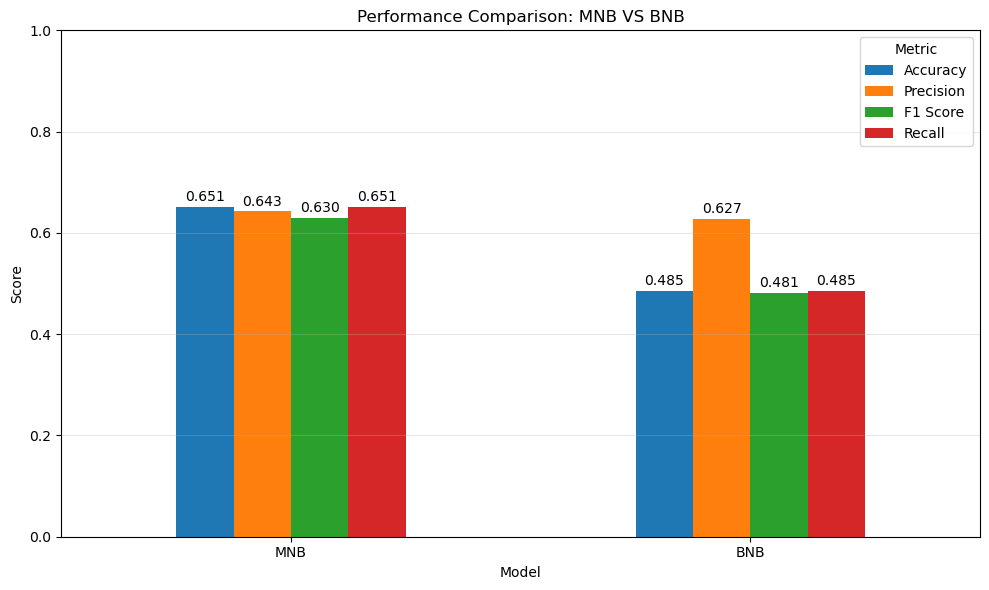

In [60]:
import matplotlib.pyplot as plt

ax = results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison: MNB VS BNB")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)

# Add values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2)

plt.tight_layout()
plt.show()




In [63]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [65]:
y_test_bin = label_binarize(
y_test,
classes=mnb.classes_
)

mnb_prob = mnb.predict_proba(X_test)
bnb_prob = bnb.predict_proba(X_test_binary)

In [67]:
fpr_mnb, tpr_mnb, _ = roc_curve(
y_test_bin.ravel(),
mnb_prob.ravel()
)

fpr_bnb, tpr_bnb, _ = roc_curve(
y_test_bin.ravel(),
bnb_prob.ravel()
)

mnb_auc = auc(fpr_mnb, tpr_mnb)
bnb_auc = auc(fpr_bnb, tpr_bnb)

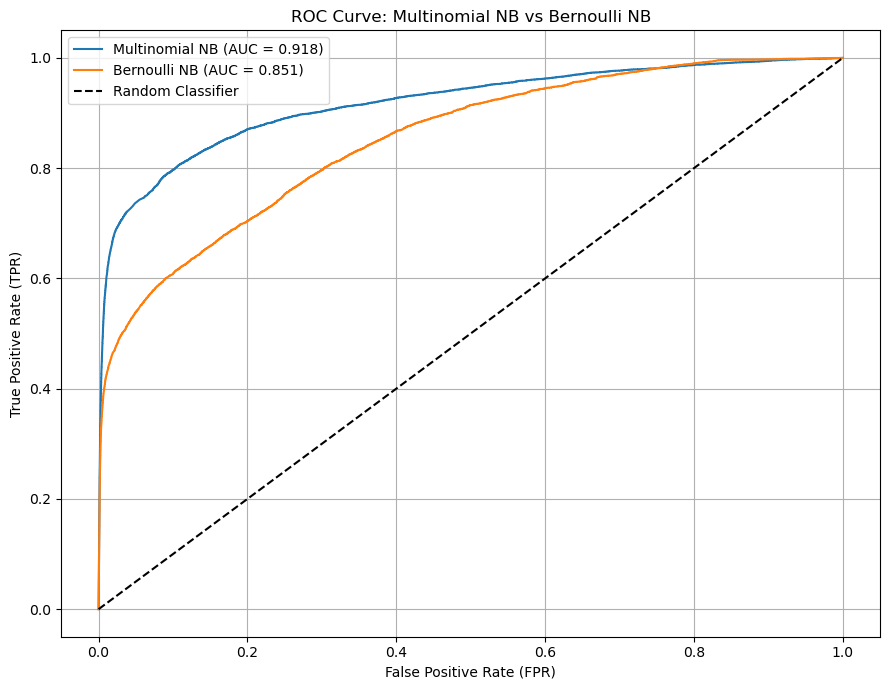

In [68]:
plt.figure(figsize=(9, 7))

plt.plot(
fpr_mnb,
tpr_mnb,
label=f'Multinomial NB (AUC = {mnb_auc:.3f})'
)

plt.plot(
fpr_bnb,
tpr_bnb,
label=f'Bernoulli NB (AUC = {bnb_auc:.3f})'
)

plt.plot(
[0, 1],
[0, 1],
'k--',
label='Random Classifier'
)

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve: Multinomial NB vs Bernoulli NB')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

